# Import Packages

In [1]:
from glob import glob
import random
import warnings
from cmcrameri import cm
import numpy as np
from IPython.display import display
from pathlib import Path
from pandas import DataFrame, concat, read_parquet
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.figure import Figure
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import re
import contextily as ctx
import geopandas as gpd
import pydeck as pdk
import plotly.graph_objects as go

import func_gev as gev
import func_preparation as dbf
import func_plotting as dbplt
import func_utils as ut

warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline
CMAP = cm.vik

fs = 12

# Settings

In [2]:
path_data = '../input/Annual_max_DCPP_20260112/'
path_export = '../output/update/'
path_results = '../output/gev_analysis/2026-05-20/'

#dir_data_pkl = path_results + '/data.parquet'

In [3]:
HINDCAST_START = 1961
HINDCAST_END = 2026

In [4]:
axes_color: str = '#333333'
markers_color: str = "#99E3DDFF"
colors_reg: list = ['#333333FF', '#7F6C7BFF']  

In [5]:
RETURN_PERIODS = [10, 25, 50, 100, 200]
PLOT_PERIOD_EVOLUTION = ['10-year', '50-year', '100-year']

In [6]:
CONFIDENCE_INTERVAL = 0.9 # two-side 90% CI interval (5% each side)

In [7]:
# adding a little randomness to enhance trust the model works as robust as possible cross locations..
start_location = 0 #random.choice(arange(0, 9579))
end_location = 2000 #start_location+10

print(f'analyse a subsample of location {start_location}–{end_location}')

analyse a subsample of location 0–2000


# Import Data

### Import Raw Data from Models

In [8]:
ls_files = [file for file in glob(path_data + '*.nc')]
print(f'found {len(ls_files)} files')

found 8 files


In [9]:
dic_data_per_model = dbf.import_all_models(ls_files)

### Import regression results for location trend regression

In [10]:
[
    results_annual_stat_all, results_nonstat_all, location_geo_info, location_point_info
    ] = ut.import_info_for_regression(path_results)

loading ../output/gev_analysis/2026-05-20//stationary_per_year.pkl
loading ../output/gev_analysis/2026-05-20//nonstationary.pkl
loading ../output/gev_analysis/2026-05-20//LatLon.pkl
loading ../output/gev_analysis/2026-05-20//location_info.pkl


In [11]:
results_stat_all = ut.import_pickle_data(path_results, 'stationary.pkl')

loading ../output/gev_analysis/2026-05-20//stationary.pkl


In [12]:
raw_data = read_parquet(path_results + 'data.parquet')

# Data Processing...

### BiasCorrection,...

In [ ]:
dic_data_per_model, combined, notes_overview = dbf.prepare_combined_data(ls_files, dic_data_per_model)

In [ ]:
dic_data_per_location = dbf.extract_location_data(combined, HINDCAST_START, HINDCAST_END)

# VISUALS

## Map of Missing Data

In [ ]:
n_obs_per_location = dbf.get_number_of_observations_per_site(dic_data_per_location)
n_obs_per_location

In [ ]:
df_missing_location, df_valid, fig_map = dbf.create_summary_location_w_missing_data(
    dic_data_per_model=dic_data_per_model, combined=combined, n_obs_per_location=n_obs_per_location,
    radius_marker_m=5000, dir_export='../output/gev_analysis/2026-03-20/', print_msg=True
    )

In [ ]:
display(fig_map)

## μ Regression - Non-stationary vs annual stationary per location

compute with standardized or non-standardized years

##### Compute for 1 Location

In [ ]:
ls_missing = []
loc_id = random.choice(list(results_annual_stat_all.keys()))

print(f'Compute regression analysis for μ₁ for site {loc_id}...')

In [ ]:
if results_nonstat_all[loc_id] is None:
    ls_missing.append(loc_id)
    print(f'Could not process side {loc_id}, NO nonstationary results available (counting {len(ls_missing)})')

years_, dic_trend = gev.prepare_for_regression(    
    annual_stationary=results_annual_stat_all[loc_id], 
    nonstationary=results_nonstat_all[loc_id],
    confidence_level_pc=CONFIDENCE_INTERVAL, factor_m_to_mm=1000,
    years_scaled=True
    ) 

In [ ]:
fig_reg = dbplt.plot_location_regression(
    loc_id, years_, dic_trend, results_annual_stat_all[loc_id], 
    confidence_level_pc=CONFIDENCE_INTERVAL, display_results=True, years_scaled=True,
    axes_color='#333333', markers_color="#99E3DDFF", colors_reg=['#CAA5C2FF', '#005C55FF'], 
    fontsize=12, 
    )

#### Compute for All

In [ ]:
dic_fig_regression = {}
ls_missing = []
for loc_id in results_annual_stat_all.keys():
    if loc_id >= start_location and loc_id <= end_location:
        print(f'processing site {loc_id}...')
        
        if results_nonstat_all[loc_id] is None:
            ls_missing.append(loc_id)
            print(f'Skipping side {loc_id}, no nonstationary results (counting {len(ls_missing)})')
            dic_fig_regression[loc_id] = None
            continue
        
        years_, dic_trend = gev.prepare_for_regression(            
            annual_stationary=results_annual_stat_all[loc_id], nonstationary=results_nonstat_all[loc_id],
            confidence_level_pc=CONFIDENCE_INTERVAL, factor_m_to_mm=1000, years_scaled=True
            ) 

        fig_reg = dbplt.plot_location_regression(
            loc_id, years_, dic_trend, results_annual_stat_all[loc_id], fontsize=12,
            confidence_level_pc=CONFIDENCE_INTERVAL, years_scaled=True,
            axes_color='#333333', markers_color="#99E3DDFF", colors_reg=['#CAA5C2FF',  '#005C55FF'], 
            )
        
        dic_fig_regression[loc_id] = fig_reg

In [ ]:
for loc_id in dic_fig_regression.keys():
    if dic_fig_regression[loc_id]:
        ut.store_location_regression(
            dic_fig_regression[loc_id],loc_id, 
            location_geo_info[loc_id], location_point_info[loc_id], 
            Path('../output/gev_analysis/2026-03-20/')
            )

## Maps of Fit Parameters

In [ ]:
threshold_z_outlier = 3
export_path = '../output/gev_analysis/update/maps/'

### Scale σ parameter

In [ ]:
parameter='scale'
unit = 'm'

ls_options_approach = ['annual-stationary', 'non-stationary', 'stationary']
ls_options_outlier = [True, False]
ls_options_interactive = [True, False]

n_total = len(ls_options_approach) * len(ls_options_outlier) * len(ls_options_interactive)

In [ ]:
n = 0 
for approach in ls_options_approach:
    for mark_outlier in ls_options_outlier:
        for interactive_map in ls_options_interactive:
            min_size = 2000 if interactive_map is True else 2.5
            max_size = 20000 if interactive_map is True else 35
            marker_size = 10000 if interactive_map is True else 7.5
            
            print(f'\nplot combination {n+1} out of {n_total}...')
            print('\tapproach', approach, '| mark_outlier', mark_outlier, '| interactive_map', interactive_map)
            if approach == 'non-stationary':
                df=results_nonstat_all
            elif approach == 'annual-stationary':
                df=results_annual_stat_all
            elif approach == 'stationary':
                df=results_stat_all

            fig_map = dbplt.plot_map_for_parameter(
                approach=approach, parameter=parameter, unit=unit, df=df, location_geo_info=location_geo_info,
                confidence_level_pc=CONFIDENCE_INTERVAL, threshold_z_outlier=threshold_z_outlier, 
                mark_outlier=mark_outlier, interactive_map=interactive_map, cmap=CMAP, marker_size=marker_size,
                min_size=min_size, max_size=max_size, saving_map=True, save_path=export_path, fs=12
                )
            n +=1

### Shape ξ parameter

In [ ]:
parameter='shape'
unit = '1'

ls_options_approach = ['annual-stationary', 'non-stationary', 'stationary']
ls_options_outlier = [True, False]
ls_options_interactive = [True, False]

n_total = len(ls_options_approach) * len(ls_options_outlier) * len(ls_options_interactive)

In [ ]:
n = 0 
for approach in ls_options_approach:
    for mark_outlier in ls_options_outlier:
        for interactive_map in ls_options_interactive:
            min_size = 2000 if interactive_map is True else 2.5
            max_size = 20000 if interactive_map is True else 35
            marker_size = 10000 if interactive_map is True else 7.5
            
            print(f'\nplot combination {n+1} out of {n_total}...')
            print('\tapproach', approach, '| mark_outlier', mark_outlier, '| interactive_map', interactive_map)
            if approach == 'non-stationary':
                df=results_nonstat_all
            elif approach == 'annual-stationary':
                df=results_annual_stat_all
            elif approach == 'stationary':
                df=results_stat_all

            fig_map = dbplt.plot_map_for_parameter(
                approach=approach, parameter=parameter, unit=unit, df=df, location_geo_info=location_geo_info,
                confidence_level_pc=CONFIDENCE_INTERVAL, threshold_z_outlier=threshold_z_outlier, 
                mark_outlier=mark_outlier, interactive_map=interactive_map, cmap=CMAP, marker_size=marker_size,
                min_size=min_size, max_size=max_size, saving_map=True, save_path=export_path, fs=12
                )
            n +=1

### Location μ parameter

In [ ]:
parameter='mu'
unit = 'm'

ls_options_approach = ['annual-stationary', 'non-stationary', 'stationary']
ls_options_outlier = [True, False]
ls_options_interactive = [True, False]

n_total = len(ls_options_approach) * len(ls_options_outlier) * len(ls_options_interactive)

In [ ]:
n = 0 
for approach in ls_options_approach:
    for mark_outlier in ls_options_outlier:
        for interactive_map in ls_options_interactive:
            min_size = 2000 if interactive_map is True else 2.5
            max_size = 20000 if interactive_map is True else 35
            marker_size = 10000 if interactive_map is True else 7.5
            
            print(f'\nplot combination {n+1} out of 12...')
            print('\tapproach', approach, '| mark_outlier', mark_outlier, '| interactive_map', interactive_map)
            if approach == 'non-stationary':
                df=results_nonstat_all
            elif approach == 'annual-stationary':
                df=results_annual_stat_all
            elif approach == 'stationary':
                df=results_stat_all

            fig_map = dbplt.plot_map_for_parameter(
                approach=approach, parameter=parameter, unit=unit, df=df, location_geo_info=location_geo_info,
                confidence_level_pc=CONFIDENCE_INTERVAL, threshold_z_outlier=threshold_z_outlier, 
                mark_outlier=mark_outlier, interactive_map=interactive_map, cmap=CMAP, marker_size=marker_size,
                min_size=min_size, max_size=max_size, saving_map=True, save_path=export_path, fs=12
                )
            n +=1

### Location Trend μ₁

$μ_1$ with the color indicating the absolute value and the size indicating the std of $μ_1$ 

In [ ]:
parameter='mu1'
unit = 'mm/year'

ls_options_approach = ['annual-stationary', 'non-stationary']
ls_options_outlier = [True, False]
ls_options_interactive = [True, False]

n_total = len(ls_options_approach) * len(ls_options_outlier) * len(ls_options_interactive)

In [ ]:
n = 0 
for approach in ls_options_approach:
    for mark_outlier in ls_options_outlier:
        for interactive_map in ls_options_interactive:
            min_size = 2000 if interactive_map is True else 2.5
            max_size = 20000 if interactive_map is True else 35
            marker_size = 10000 if interactive_map is True else 7.5
            
            print(f'\nplot combination {n+1} out of 8...')
            print('\tapproach', approach, '| mark_outlier', mark_outlier, '| interactive_map', interactive_map)
            if approach == 'non-stationary':
                df=results_nonstat_all
            elif approach == 'annual-stationary':
                df=results_annual_stat_all

            fig_map = dbplt.plot_map_for_parameter(
                approach=approach, parameter=parameter, unit=unit, df=df, location_geo_info=location_geo_info,
                confidence_level_pc=CONFIDENCE_INTERVAL, threshold_z_outlier=threshold_z_outlier, 
                mark_outlier=mark_outlier, interactive_map=interactive_map, cmap=CMAP, marker_size=marker_size,
                min_size=min_size, max_size=max_size, saving_map=True, save_path=export_path, fs=12
                )
            n +=1

## Map ReturnPeriod

using median rather than mean

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import contextily as ctx

BASE_YEAR = 1961
PLOT_YEAR = 2026
PARAMETER = "return_period_2026"
FACTOR_M_TO_MM = 1000
threshold_z_method = 3
OUTLIER_MARKER_SIZE = 50
OUTLIER_COLOR = [200, 50, 200, 180]

lw_marker=0.1
edgecolor_marker = None
fontsize = 12

In [ ]:
def extract_return_period_summary_fast(
    results_nonstat_all,
    location_geo_info,
    base_year=1961,
    plot_year=2026,
):
    rows = []

    for loc_id, res in results_nonstat_all.items():
        if res is None or "return_period" not in res:
            continue

        rp = res["return_period"]

        if base_year not in rp.index or plot_year not in rp.index:
            continue

        lat, lon = location_geo_info[loc_id]

        base = rp.loc[base_year]
        present = rp.loc[plot_year]

        base_med = base["return_period_median"]
        pres_med = present["return_period_median"]

        rows.append((
            loc_id,
            lat,
            lon,
            base_med,
            (base["return_period_upper"] - base["return_period_lower"]) / 2,
            pres_med,
            (present["return_period_upper"] - present["return_period_lower"]) / 2,
            pres_med / base_med,
            pres_med - base_med,
        ))

    return pd.DataFrame(
        rows,
        columns=[
            "loc_id", "lat", "lon",
            "return_period_base_year",
            "return_period_base_year_margin_of_error",
            "return_period_2026",
            "return_period_2026_margin_of_error",
            "return_period_ratio_2026_vs_base",
            "return_period_change_abs",
        ],
    )

In [ ]:
df_rp = extract_return_period_summary_fast(
    results_nonstat_all=results_nonstat_all,
    location_geo_info=location_geo_info,
    base_year=BASE_YEAR,
    plot_year=PLOT_YEAR,
)

print(df_rp[[
    "return_period_base_year",
    "return_period_2026",
    "return_period_ratio_2026_vs_base",
    "return_period_change_abs"
]].describe())

static map

In [ ]:
df_rp["return_period_2026"].describe()


In [ ]:
df_rp["return_period_ratio_2026_vs_base"].describe()

In [ ]:
df_rp["return_period_base_year"].describe()


old approach

In [ ]:
lw_marker=0.1
edgecolor_marker = None
fontsize = 12
threshold_z_method = 3

mark_outlier = True
parameter = 'return_period_2026'
plot_year = 2026
base_year = 1961

OUTLIER_MARKER_SIZE = 50
OUTLIER_COLOR = [200, 50, 200, 180]

export_path = '../output/gev_analysis/2026-03-31/figures/'

In [ ]:
def get_return_period_for_50yr_event_per_site(loc_id, results_nonstat_all, location_geo_info):
        df_return_period_location = results_nonstat_all[loc_id]['return_period'].drop_duplicates()
        df = DataFrame(location_geo_info[loc_id]).T
        
        n = df_return_period_location.shape[0]

        df_repeated = df.loc[df.index.repeat(n)].reset_index(drop=True)
        df_repeated.columns = ['lat', 'lon']
        df_repeated.index = df_return_period_location.index
        return concat([df_return_period_location, df_repeated], axis=1)

# -----------------------------------------------------------------------
dic_return_period_50yr = {}
for loc_id in results_nonstat_all.keys():
    dic_return_period_50yr[loc_id] = get_return_period_for_50yr_event_per_site(
        loc_id, results_nonstat_all, location_geo_info
        )


In [ ]:
def get_return_period_overview(dic_return_period_50yr):
    ls_return_period_50yr_comparison = []
    for loc_id in dic_return_period_50yr.keys():
        print(f"\rprocess site {loc_id}", end='')
        lat, lon = dic_return_period_50yr[loc_id]['lat'].unique()[0], dic_return_period_50yr[loc_id]['lon'].unique()[0]
        
        start, end = dic_return_period_50yr[loc_id].index[[0, -1]]
        
        if end == 2024 or end == 2026:
            end = 2023
            
        df_std = (dic_return_period_50yr[loc_id]['return_period_upper'] - dic_return_period_50yr[loc_id]['return_period_lower'])/2
        if HINDCAST_END in dic_return_period_50yr[loc_id].index:
            df_2026 = dic_return_period_50yr[loc_id].loc[HINDCAST_END].filter(like='median').values[0]
            df_2026_moe = df_std.loc[HINDCAST_END]
        else:
            df_2026 = None
            df_2026_moe = None
        
        
        ls_return_period_50yr_comparison.append([
            lat, lon,
            start, dic_return_period_50yr[loc_id].loc[start].filter(like='median').values[0], df_std.loc[start],
            end, dic_return_period_50yr[loc_id].loc[end].filter(like='median').values[0], df_std.loc[end],
            HINDCAST_END, df_2026, df_2026_moe
            ])
        
    return DataFrame(
        ls_return_period_50yr_comparison, 
        columns=[
            'lat', 'lon', 
            'base_year', 'return_period_base_year',  'return_period_base_year_margin_of_error',  
            'end_of_comparison', 'return_period_end_year', 'return_period_end_year_margin_of_error',  
            'present_year', 'return_period_2026', 'return_period_2026_margin_of_error'
            ]
        )
    
# ----------------------------------------------------------------------- 
df_return_period_50yr_comparison = get_return_period_overview(dic_return_period_50yr)

In [ ]:
df_return_period_50yr_comparison.shape[0] - df_return_period_50yr_comparison.dropna().shape[0]

... sites have missing values, either because their simulation does not reach 2026 or the return period could not be computed at all

In [ ]:
df_return_period_50yr_comparison[df_return_period_50yr_comparison.end_of_comparison == 1961]

For 4 sites, the return period could not be computed...

Each site should at least have predictions until 2023... plot both, 2026 (for those it is possible) and for 2023

In [ ]:
df_return_period_50yr_2026_ = df_return_period_50yr_comparison.return_period_2026.dropna()
df_return_period_50yr_2026 = df_return_period_50yr_comparison.loc[df_return_period_50yr_2026_.index]

df_return_period_50yr_2026 = df_return_period_50yr_2026[df_return_period_50yr_2026.base_year == 1961]

In [ ]:
df_return_period_50yr_2026.loc[df_return_period_50yr_2026.return_period_2026.idxmax()]

In [ ]:
if mark_outlier is True:
    df_return_period_50yr_2026 = ut.mark_outliers_zmethod(
        df_return_period_50yr_2026, 'return_period_2026', threshold=threshold_z_method
        )

### interactive Map

In [30]:
def create_gradient_legend(
    cmap, norm, threshold_z_method, mark_outlier, parameter, unit, width=180, height=15, n_steps=100
    ):
    """
    Create an HTML gradient legend matching your colormap and normalization.

    cmap: matplotlib colormap
    norm: matplotlib TwoSlopeNorm or Normalize
    width: width of the legend in px
    height: height of the gradient bar in px
    n_steps: number of gradient steps
    """
    # generate colors
    gradient = []
    for i in range(n_steps):
        val = norm.vmin + i / (n_steps-1) * (norm.vmax - norm.vmin)
        rgba = cmap(norm(val))
        r, g, b = [int(255*c) for c in rgba[:3]]
        gradient.append(f"rgb({r},{g},{b})")

    gradient_str = ",".join(gradient)

    # HTML for gradient legend
    if parameter == 'mu':
        parameter_pretty = 'μ'
    elif parameter == 'mu1':
        parameter_pretty = 'μ₁' 
    elif parameter == 'scale':
        parameter_pretty = 'σ'
    elif parameter == 'shape':
        parameter_pretty = 'ξ'
    elif 'return_period' in parameter:
        parameter_pretty = 'return period'
    
    if mark_outlier is True:
        legend_html = f"""
        <div style="
            position: fixed;
            bottom: 40px;
            left: 40px;
            width: {width}px;
            font-size: 12px;
            background-color: white;
            border-radius: 6px;
            box-shadow: 0px 0px 6px rgba(0,0,0,0.3);
            padding: 6px;
            z-index: 9999;
        ">
            <b>Trend {parameter_pretty}, {unit}</b><br>
            <div style="
                height: {height}px;
                background: linear-gradient(to right, {gradient_str});
                border: 1px solid black;
                margin: 4px 0;
            "></div>
            <div style="display:flex;justify-content:space-between;">
                <span>{norm.vmin:.2f}</span>
                <span>0</span>
                <span>{norm.vmax:.2f}</span>
            </div>
            <br>
            <b>Transparency</b><br>
            Higher uncertainty → higher transparency
            <br>
            <b>Outlier marked</b><br>
            <span>using modified Z-score method with threshold {threshold_z_method:.2f}· σ</span>
        </div>
        """
    else:
        legend_html = f"""
        <div style="
            position: fixed;
            bottom: 40px;
            left: 40px;
            width: {width}px;
            font-size: 12px;
            background-color: white;
            border-radius: 6px;
            box-shadow: 0px 0px 6px rgba(0,0,0,0.3);
            padding: 6px;
            z-index: 9999;
        ">
            <b>Trend {parameter_pretty}, {unit}</b><br>
            <div style="
                height: {height}px;
                background: linear-gradient(to right, {gradient_str});
                border: 1px solid black;
                margin: 4px 0;
            "></div>
            <div style="display:flex;justify-content:space-between;">
                <span>{norm.vmin:.2f}</span>
                <span>0</span>
                <span>{norm.vmax:.2f}</span>
            </div>
            <br>
            <b>Transparency</b><br>
            Higher uncertainty → higher transparency
        </div>
        """
    #    More transparent → higher uncertainty
    # ALTERNATIVE: bigger marker size → higher uncertainty

    return legend_html



In [ ]:
inital_zoom = 3.5

In [ ]:
df_plot = df_return_period_50yr_2026.copy()
df_plot["marker_size"] = 10000


for suffix in ["",]:
    col = parameter + suffix
    df_plot[col + "_str"] = df_plot[col].map("{:.3f}".format)
        
df_plot["lat_str"] = df_plot["lat"].map("{:.3f}".format)
df_plot["lon_str"] = df_plot["lon"].map("{:.3f}".format)

# ---- Turn Value into Color ----
if mark_outlier:
    df_plot["status"] = df_plot["outliers"].apply(
        lambda x: "invalid (outlier)" if x else "valid"
    )
    data = df_plot.loc[~df_plot["outliers"], parameter]
else:
    data = df_plot[parameter]

min_value = np.nanmin(data)
max_value = np.nanmax(data)
norm = mcolors.Normalize(vmin=min_value, vmax=max_value)

def mu_to_color(val):
    rgba = CMAP(norm(val))
    return [int(255*c) for c in rgba[:3]]
df_plot["color"] = df_plot[parameter].apply(mu_to_color)

max_se = np.nanpercentile(abs(df_plot[parameter+'_margin_of_error']), 98)
def se_to_alpha(se):
    norm_se = min(se / max_se, 1)
    if np.isnan(norm_se):
        alpha = int(10)
    else:
        alpha = int(255 * (1 - norm_se))      
    return max(alpha, 10)  # prevent fully invisible

df_plot["alpha"] = df_plot[parameter+"_margin_of_error"].apply(se_to_alpha)
df_plot["color_rgba"] = df_plot.apply(lambda row: row["color"] + [row["alpha"]],axis=1)

if mark_outlier:    
    df_plot["color_rgba"] = df_plot.apply(
        lambda row: OUTLIER_COLOR if row["outliers"] else row["color_rgba"], axis=1
        )
    #df_plot["marker_size"] = df_plot.apply(
    #    lambda row: 20000 if row["outliers"] else row["marker_size"], axis=1
    #    )

In [ ]:
# ---- Plotting ----
layer = pdk.Layer(
    "ScatterplotLayer",
    data=df_plot,
    get_position='[lon, lat]',
    get_fill_color="color_rgba",
    get_radius="marker_size",
    pickable=True,
)

# ---- View ----
view_state = pdk.ViewState(
    latitude=df_plot["lat"].mean(), longitude=df_plot["lon"].mean(), zoom=inital_zoom,
)

legend_html = create_gradient_legend(
    CMAP, norm, threshold_z_method, mark_outlier=mark_outlier, parameter=parameter, unit='yr', width=260, height=15, 
    n_steps=100
)

label_para = parameter + "_str"
status_line = "status: {status}<br>" if mark_outlier else ""

tooltip_html = f"""
    <b>ReturnPeriod of 50-yr event (base {base_year})</b><br>
    Lat: {{lat_str}}<br>
    Lon: {{lon_str}}<br>
    ReturnPeriod in {plot_year}: {{{label_para}}} yr<br>
    {status_line}
"""

dic_tooltip = {
    "html": tooltip_html,
    "style": {
        "backgroundColor": "lightgray",
        "color": axes_color,
        "padding": "8px"
    }
}

deck = pdk.Deck(
    layers=[layer],
    initial_view_state=view_state,
    map_style="https://tiles.openfreemap.org/styles/positron",
    tooltip=dic_tooltip
)

save_dir = Path(export_path)
save_dir.mkdir(parents=True, exist_ok=True) 

if mark_outlier is True:
    file_name = f'Map_ReturnPeriod_of_50yrEvent_in_{plot_year}_markedOutlier'
else:
    file_name = f'Map_ReturnPeriod_of_50yrEvent_in_{plot_year}'
    
full_path = (save_dir / file_name).with_suffix('.html')
print(f"map stored as {full_path}")

deck.to_html(full_path)

with open(full_path, "r", encoding="utf-8") as f:
    html = f.read()

html = re.sub(
    r"<title>.*?</title>",
    f"<title>Map ReturnPeriod</title>",
    html,
    flags=re.IGNORECASE
)
html = html.replace("</body>", legend_html + "\n</body>")

with open(full_path, "w", encoding="utf-8") as f:
    f.write(html)


NameError: name 'df_plot' is not defined

### static Map

In [ ]:
gdf = gpd.GeoDataFrame(
    df_return_period_50yr_2026, 
    geometry=gpd.points_from_xy(df_return_period_50yr_2026['lon'], df_return_period_50yr_2026['lat']), 
    crs="EPSG:4326"
    )
gdf_web = gdf.to_crs(epsg=3857)

In [ ]:
df = gdf_web.copy()
    
if mark_outlier is True:
    valid = gdf_web.loc[~gdf_web["outliers"], parameter]
    min_value = np.nanmin(valid)
    max_value = np.nanmax(valid)
else:
    max_value = np.nanmax(gdf_web[parameter])
    min_value = np.nanmin(gdf_web[parameter]) 
    
norm = mcolors.Normalize(vmin=min_value, vmax=max_value)
def mu_to_color(val):
    rgba = CMAP(norm(val))
    return [int(255*c) for c in rgba[:3]]
df["color"] = df[parameter].apply(mu_to_color)

max_se = np.nanpercentile(abs(df_plot[parameter+'_margin_of_error']), 98)
def se_to_alpha(se):
    norm_se = min(se / max_se, 1)
    if np.isnan(norm_se):
        alpha = int(10)
    else:
        alpha = int(255 * (1 - norm_se))      
    return max(alpha, 10)  # prevent fully invisible

df["alpha"] = df[parameter+"_margin_of_error"].apply(se_to_alpha)
df["color_rgba"] = df.apply(lambda row: row["color"] + [row["alpha"]],axis=1)

df["marker_size"] = 7.5
if mark_outlier is True:
    df["color_rgba"] = df.apply(
        lambda row: OUTLIER_COLOR if row["outliers"] else row["color_rgba"], axis=1
        )
#    df["marker_size"] = df.apply(
#        lambda row: OUTLIER_MARKER_SIZE if row["outliers"] else row["marker_size"], axis=1
#        )
    
colors = []
for c in df['color_rgba']:
    c_rgba = list(c)
    if len(c_rgba) == 3:
        c_rgba.append(255)
    colors.append([v/255 for v in c_rgba])
colors = np.array(colors)


In [ ]:
fig, ax = plt.subplots(figsize=(8,5))

sc = ax.scatter(
        gdf_web.geometry.x, gdf_web.geometry.y, 
        s=df['marker_size'], c=colors, edgecolor=edgecolor_marker, linewidth=lw_marker
        )

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=6)

if mark_outlier:
        legend_elements = [
                Line2D(
                [0], [0], linestyle='None', marker=None, 
                label=f"Uncertainty ~ transparency (high → highly transparent)\nOutlier marked using modified Z-score (threshold {threshold_z_method:.2f}·σ)"
                )
        ]
        ax.legend(handles=legend_elements, loc='lower right', fontsize=fontsize*0.8, framealpha=0.6)
else:
        legend_elements = [
                Line2D([0], [0], linestyle='None', marker=None, label=f"Uncertainty ~ transparency (high → highly transparent)")
                ]
ax.legend(handles=legend_elements, loc='lower right', fontsize=fontsize*0.8, framealpha=0.6)

ax.set_axis_off()
sm = ScalarMappable(cmap=CMAP, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03, pad=0.04)

plt.title(f'Return Period of a 50-year event (base year {base_year}) in {plot_year}', loc='left', fontsize=fontsize)

plt.tight_layout()
plt.show()

In [ ]:
save_dir = Path(export_path)
save_dir.mkdir(parents=True, exist_ok=True)

if mark_outlier is True:
    file_name = f'Map_ReturnPeriod_of_50yrEvent_in_{plot_year}_markedOutlier'
else:
    file_name = f'Map_ReturnPeriod_of_50yrEvent_in_{plot_year}'
    
file_name = (save_dir / file_name).with_suffix('.png')
fig.savefig(file_name, dpi=300, bbox_inches='tight')

## Comparing Return Period Evolution for interesting sites

In [ ]:
import seaborn as sns 
sns.set_style('whitegrid')

T_EVAL_BASE = 1961
RETURN_PERIOD_EVAL = 50
fs = 10
confidence_interval_pc = CONFIDENCE_INTERVAL


colors_sites = ['#005C55FF','#33C6BBFF', '#99E3DDFF','#DBC3D6FF', '#B887ADFF', '#7D4F73FF'] 
plot_reference = True
ci_level=confidence_interval_pc*100

### plot all

In [ ]:
fig = go.Figure()

for loc_id, df in dic_return_period_50yr.items():
    years = df.return_period_median.index

    fig.add_trace(
        go.Scatter(
            x=years,
            y=df.return_period_median.values,
            mode='lines',
            line=dict(width=1),
            opacity=0.15,
            name=str(loc_id),
            hoverinfo='name+y',
            showlegend=False
        )
    )

    """fig.add_trace(
        go.Scatter(
            x=list(years) + list(years[::-1]),
            y=list(df.return_period_upper.values) + list(df.return_period_lower.values[::-1]),
            fill='toself',
            fillcolor='rgba(0, 138, 128, 0.08)',
            line=dict(width=0),
            hoverinfo='skip',
            showlegend=False
        )
    )"""

T_ref = 50
fig.add_hline(
    y=T_ref,
    line_dash="dash",
    line_color="gray",
    opacity=0.6
)

fig.update_layout(
    title="Return Period Trends (50yr)",
    height=450,
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis=dict(
        title=dict(
            text="Year",
            font=dict(color="#333333")
        ),
        showgrid=True,
        gridcolor="lightgrey",
        gridwidth=1,
        zeroline=False,
        showline=True,
        linecolor="#333333",
        tickfont=dict(color="#333333")
    ),
    yaxis=dict(
        title=dict(
            text="Return period (years)",
            font=dict(color="#333333")
        ),
        showgrid=True,
        gridcolor="lightgrey",
        gridwidth=1,
        zeroline=False,
        showline=True,
        linecolor="#333333",
        tickfont=dict(color="#333333")
    ),
    showlegend=False
)

fig.show()
fig.write_html(export_path + "Overview_ReturnPeriodEvolution.html")

### select relevant examples 
from plotly above

In [ ]:
ls_site_ids = [1036,1022, 787, 4886, 6192,4272]

In [ ]:
df_rp_evol = df_return_period_50yr_2026

In [ ]:
# minimal return period
ls_site_ids = [df_rp_evol.return_period_2026.idxmin()]

In [ ]:
# average return period
target = df_rp_evol.return_period_2026.mean()
n = 1

ls_site_ids.extend(
    df_rp_evol.iloc[(df_rp_evol.return_period_2026 - target).abs().argsort()[:n]].index.to_list()
)

In [ ]:
# maximal return period (without being an outlier)
ls_site_ids.extend([df_rp_evol[df_rp_evol.outliers == False].return_period_2026.idxmax()])

In [ ]:
# maximal return period (including outliers)
#ls_site_ids.extend([df_rp_evol.return_period_2026.idxmax()])

In [ ]:
rp_per_site = [(loc_id, gev.rp_uncertainty_monte_carlo(
    params=results_nonstat_all[loc_id]['params_hat'], cov=results_nonstat_all[loc_id]['cov'],  
    years=raw_data.sim_year.unique(), mean_year=results_nonstat_all[loc_id]['years_mean'], 
    std_year=results_nonstat_all[loc_id]['years_std'], ref_year=T_EVAL_BASE, T_ref=RETURN_PERIOD_EVAL
    )) for loc_id in ls_site_ids]

In [ ]:
fig, ax = plt.subplots(figsize=(13, 4.5))

for en, site in enumerate(ls_site_ids):
    if en > len(colors_sites)-1:
        raise ValueError('Define more colors...')
    
    years = dic_return_period_50yr[site].index

    ax.plot(
        dic_return_period_50yr[site].return_period_median, color=colors_sites[en], 
        label=f"return period av. site {site}"
        )
    ax.fill_between(
        years, dic_return_period_50yr[site].return_period_lower.values, 
        dic_return_period_50yr[site].return_period_upper.values, 
        color=colors_sites[en], alpha=0.3, lw=0, label=f"{ci_level}% CI"
        )

ax.legend(loc='lower left', ncols=2, frameon=False, fontsize=fs*0.9)
ax.axhline(
    RETURN_PERIOD_EVAL, color='gray', lw=1, ls='--', alpha=0.6, 
    label=f"Original {RETURN_PERIOD_EVAL}-year event"
    )

ax.grid(True, alpha=0.3, color='lightgrey')
for spine in ax.spines.values():
    spine.set_visible(False)

rest_lower = T_EVAL_BASE%10
rest_upper = years[-1]%10
    
ax.set_xlim(T_EVAL_BASE-rest_lower, years[-1]+(10-rest_upper))

ax.axhline(y=ax.get_ylim()[0], color=axes_color, linewidth=1.2, zorder=10)
ax.axvline(x=ax.get_xlim()[0], color=axes_color, linewidth=1.2, zorder=10)
ax.tick_params(axis='x', colors=axes_color)
ax.tick_params(axis='y', colors=axes_color)

ax.set_xlabel('Year', fontsize=fs)
ax.set_ylabel(f'Return Period (years)', fontsize=fs)
ax.set_title(
    f'Evolution of the {RETURN_PERIOD_EVAL}-year return period at different sites', fontsize=fs*1.15, loc='left'
)

sns.despine(ax=ax)  
plt.tight_layout()

In [ ]:
save_dir = Path(export_path)
save_dir.mkdir(parents=True, exist_ok=True)

file_name = f'Comparison_ReturnPeriodEvolution_of_50yrEvent_'
file_name = (save_dir / file_name).with_suffix('.png')
fig.savefig(file_name, dpi=300, bbox_inches='tight')

## Return-Period Evolution of the 1961 50-year event

In [52]:
def return_period_evolution_per_site(results_nonstat_all, site_id, years, return_period_ref=50, confidence_level=90):
    nonstat_at_site = results_nonstat_all[site_id]
    rp_det = gev.return_period_evolution_1961_50yr(
        nonstationary=nonstat_at_site,
        years=years,
        ref_year=HINDCAST_START,
        ref_return_period=return_period_ref,
    )
    rp_mc = gev.return_period_evolution_1961_50yr_mc(
        nonstationary=nonstat_at_site,
        years=years,
        ref_year=HINDCAST_START,
        ref_return_period=return_period_ref,
        confidence_level=confidence_level,
        nsim=5000,
        seed=42,
    )
    
    return rp_det, rp_mc


def interpret_return_period_change(rp_df, start_year=1961, end_year=2026):
    rp_start = float(rp_df.loc[rp_df["year"] == start_year, "return_period_median"].iloc[0])
    rp_end = float(rp_df.loc[rp_df["year"] == end_year, "return_period_median"].iloc[0])

    if rp_end < rp_start:
        interpretation = "The event became more frequent."
    elif rp_end > rp_start:
        interpretation = "The event became less frequent."
    else:
        interpretation = "The event frequency did not change."

    return {
        "start_year": start_year,
        "end_year": end_year,
        "rp_start": rp_start,
        "rp_end": rp_end,
        "change": rp_end - rp_start,
        "interpretation": interpretation,
    }


### compute for 1 site

In [ ]:
site_id = 50
years = np.arange(HINDCAST_START, HINDCAST_END+1)

rp_det, rp_mc = return_period_evolution_per_site(
    results_nonstat_all, site_id, years, 
    return_period_ref=50, confidence_level=90
    )

ValueError: Quantiles must be in the range [0, 1]

In [ ]:
print(rp_det.head())
print(rp_mc.tail())

In [ ]:
# Check 2026 equivalent return period
rp_2026 = rp_mc.loc[rp_mc["year"] == 2026]
print(rp_2026)

In [ ]:
fig, ax = dbplt.plot_return_period_evolution_1961_50yr(
    rp_mc,
    ref_return_period=50,
    site_id=site_id,
)
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
interpret_return_period_change(rp_mc, 1961, 2026)

### compare selected sites

In [60]:
ls_sites = [
    8, 567, 4257, # 287, 489, 797, 1616
    141, 930, 4073, # 715, 136, 1805, 
    442, 681, 1117 # 205, 6724
    ]

In [61]:
dic_rp_det, dic_rp_mc = {}, {}
for site_id in ls_sites:
    rp_det, rp_mc = return_period_evolution_per_site(
        results_nonstat_all, site_id, years, 
        return_period_ref=50, confidence_level=.90
    )

    interpretation = interpret_return_period_change(rp_mc, 1961, 2026)
    print(f"Site {site_id}: {interpretation['interpretation']} (RP change: {interpretation['change']:.2f} years)")
    
    dic_rp_det[site_id] = rp_det
    dic_rp_mc[site_id] = rp_mc

Site 8: The event became less frequent. (RP change: 9.80 years)
Site 567: The event became less frequent. (RP change: 25.60 years)
Site 4257: The event became less frequent. (RP change: 56.37 years)
Site 141: The event became more frequent. (RP change: -0.09 years)
Site 930: The event became more frequent. (RP change: -0.28 years)
Site 4073: The event became more frequent. (RP change: -0.64 years)
Site 442: The event became more frequent. (RP change: -3.62 years)
Site 681: The event became more frequent. (RP change: -5.71 years)
Site 1117: The event became more frequent. (RP change: -22.97 years)


In [101]:
from matplotlib.colors import TwoSlopeNorm
from matplotlib.cm import ScalarMappable
import seaborn as sns

ls_selected = [567, 4257, 930, 442, 1117]

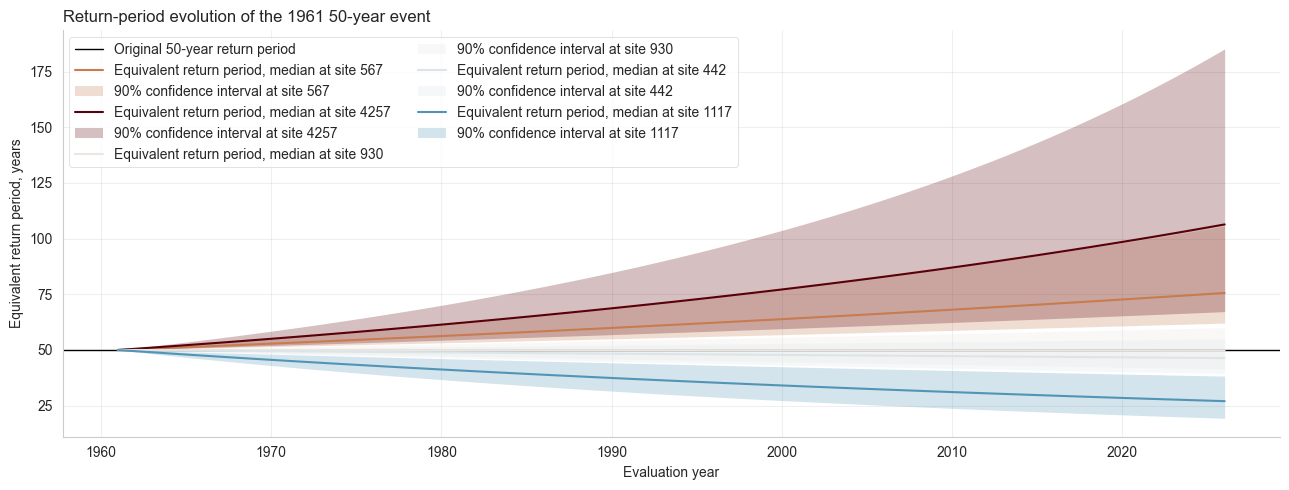

In [102]:
ref_return_period = 50

fig, ax = plt.subplots(figsize=(13, 5))

all_vals = np.concatenate([
    rp_mc["return_period_median"].replace([np.inf, -np.inf], np.nan).dropna().values
    for site_id, rp_mc in dic_rp_mc.items() if site_id in ls_selected
])

vmin = np.nanmin(all_vals)
vmax = np.nanmax(all_vals)

vmax_abs = max(abs(vmin - ref_return_period), abs(vmax - ref_return_period))
vmin_plot = ref_return_period - vmax_abs
vmax_plot = ref_return_period + vmax_abs

norm = TwoSlopeNorm(
    vmin=vmin_plot,
    vcenter=ref_return_period,
    vmax=vmax_plot,
)

# ------------------------------------------------------------------------------------- 
ax.axhline(
    ref_return_period,
    linestyle="-",
    lw=1,
    color='k',
    label=f"Original {ref_return_period}-year return period",
)

for site_id, rp_mc in dic_rp_mc.items():
    if site_id not in ls_selected:
        continue

    rp_end = float(
        rp_mc.loc[rp_mc["year"] == 2026, "return_period_median"].iloc[0]
    )

    color = CMAP(norm(rp_end))
    
    ax.plot(
        rp_mc["year"],
        rp_mc["return_period_median"],
        lw=1.5,
        color=color,
        label=f"Equivalent return period, median at site {site_id}",
    )

    ax.fill_between(
        rp_mc["year"],
        rp_mc["return_period_lower"],
        rp_mc["return_period_upper"],
        alpha=0.25,
        color=color,
        lw=0,
        label=f"90% confidence interval at site {site_id}",
    )
    

title = "Return-period evolution of the 1961 50-year event"
ax.set_title(title, loc='left')
ax.set_xlabel("Evaluation year")
ax.set_ylabel("Equivalent return period, years")
ax.grid(True, alpha=0.3)
leg = ax.legend(ncols=2)
leg.get_frame().set_linewidth(0.5)

sns.despine()
plt.tight_layout()


In [103]:
fig.savefig('../output/gev_analysis/2026-05-20/figures/ReturnPeriodEvolution_SelectedSites.png', dpi=300, bbox_inches='tight')

### compute and plot all sites

In [14]:
df_rp2026 = gev.compute_return_period_2026_all_sites_parallel(
    nonstat_all=results_nonstat_all,
    location_geo_info=location_geo_info,
    eval_year=2026,
    ref_year=1961,
    ref_return_period=50,
    nsim=1000,
    n_jobs=-1,
    seed=42,
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:   10.1s
[Parallel(n_jobs=-1)]: Done 116 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 466 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 816 tasks      | elapsed:  2.1min
/Users/silviazieger/Coding/Python/UniCat_SeaLevelExtremes/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/silviazieger/Coding/Python/UniCat_SeaLevelExtremes/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1616: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/silviazieger/Coding/Python/UniCat_SeaLevelExtremes/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Use

In [16]:
df_rp2026.to_csv('../output/gev_analysis/2026-05-20/return_period_2026_all_sites.csv', index=False)

In [17]:
df_rp2026

,site_id,lat,lon,return_period_2026,return_period_lower,return_period_upper,z_ref_median
0,0,27.731363,-18.157674,51.877976,46.319840,59.037671,0.226576
1,1,27.792446,-18.156254,51.780783,46.517710,58.585574,0.227196
2,2,27.696402,-18.108071,51.694163,46.085169,59.468458,0.224952
3,3,27.759870,-18.107191,52.137251,46.548787,59.442736,0.226969
4,4,28.771595,-18.064526,59.575134,53.417103,71.980768,0.243547
...,...,...,...,...,...,...,...
9584,9584,34.568596,35.991938,49.028701,41.429938,58.688369,0.353508
9585,9585,36.498109,36.000442,61.077122,35.940836,155.703255,0.425225
9586,9586,36.535215,36.038422,61.105229,36.642808,133.422894,0.465179
9587,9587,36.559169,36.095013,60.804437,35.156974,122.224177,0.470212


In [19]:
def prepare_rp2026_for_plot(
    df_rp2026,
    threshold_z_outlier=3.0,
    mark_outlier=True,
):
    df_plot = df_rp2026.copy()

    # main mapped variable
    parameter = "return_period_2026"

    # uncertainty width
    df_plot["return_period_2026_std"] = (
        df_plot["return_period_upper"] - df_plot["return_period_lower"]
    ) / 2

    # CI columns expected by tooltip functions
    df_plot["ci_lower"] = df_plot["return_period_lower"]
    df_plot["ci_upper"] = df_plot["return_period_upper"]

    # outliers using modified z-score / robust MAD
    if mark_outlier:
        x = df_plot[parameter].replace([np.inf, -np.inf], np.nan)
        med = np.nanmedian(x)
        mad = np.nanmedian(np.abs(x - med))

        if mad == 0 or np.isnan(mad):
            df_plot["outliers"] = False
        else:
            mz = 0.6745 * (x - med) / mad
            df_plot["outliers"] = np.abs(mz) > threshold_z_outlier
    else:
        df_plot["outliers"] = False

    return df_plot

def get_return_period_plot_labels(parameter):
    if parameter == "return_period_2026":
        return (
            "Return period in 2026 of the 1961 50-year event",
            "Return period in 2026, years",
            "T₂₀₂₆",
            "Return period"
        )
    raise ValueError(f"Unknown parameter: {parameter}")

In [36]:
def plot_return_period_2026_interactive(
    df_rp2026,
    marker_size=3500,
    inital_zoom=3.5,
    mark_outlier=True,
    threshold_z_outlier=3.0,
    saving_map=False,
    save_path=None,
    file_name="Map_ReturnPeriod2026_of_1961_50yrEvent",
    axes_color="#333333",
):
    import pydeck as pdk
    import numpy as np
    import re
    from pathlib import Path

    parameter = "return_period_2026"
    unit = "years"

    df_plot = prepare_rp2026_for_plot(
        df_rp2026,
        threshold_z_outlier=threshold_z_outlier,
        mark_outlier=mark_outlier,
    )

    df_plot = dbplt.custom_color_for_parameter(
        df_plot,
        parameter=parameter,
        mark_outlier=mark_outlier,
        min_size=10,
        max_size=200,
    )

    for col in [
        "return_period_2026",
        "return_period_2026_std",
        "return_period_lower",
        "return_period_upper",
        "z_ref_median",
    ]:
        df_plot[col + "_str"] = df_plot[col].map("{:.2f}".format)

    df_plot["lat_str"] = df_plot["lat"].map("{:.3f}".format)
    df_plot["lon_str"] = df_plot["lon"].map("{:.3f}".format)

    if mark_outlier:
        df_plot["status"] = df_plot["outliers"].apply(
            lambda x: "invalid/outlier" if x else "valid"
        )

    norm = dbplt.get_norm_for_parameter(df_plot, parameter, mark_outlier)

    layer = pdk.Layer(
        "ScatterplotLayer",
        data=df_plot,
        get_position="[lon, lat]",
        get_fill_color="color_rgba",
        get_radius=marker_size,
        pickable=True,
    )

    view_state = pdk.ViewState(
        latitude=df_plot["lat"].mean(),
        longitude=df_plot["lon"].mean(),
        zoom=inital_zoom,
    )

    status_line = "Status: {status}<br>" if mark_outlier else ""

    tooltip_html = f"""
        <b>2026 return period of 1961 50-year event</b><br>
        Lat: {{lat_str}}<br>
        Lon: {{lon_str}}<br>
        T₂₀₂₆: {{return_period_2026_str}} years<br>
        90% CI: {{return_period_lower_str}}–{{return_period_upper_str}} years<br>
        z₅₀,₁₉₆₁: {{z_ref_median_str}} m<br>
        {status_line}
    """

    deck = pdk.Deck(
        layers=[layer],
        initial_view_state=view_state,
        map_style="https://tiles.openfreemap.org/styles/positron",
        tooltip={
            "html": tooltip_html,
            "style": {
                "backgroundColor": "lightgray",
                "color": axes_color,
                "padding": "8px",
            },
        },
    )

    legend_html = create_gradient_legend(
        cmap=CMAP,
        norm=norm,
        threshold_z_method=threshold_z_outlier,
        mark_outlier=mark_outlier,
        parameter=parameter,
        unit=unit,
        width=280,
        height=15,
        n_steps=100,
    )

    if saving_map:
        save_dir = Path(save_path)
        save_dir.mkdir(parents=True, exist_ok=True)

        full_path = (save_dir / file_name).with_suffix(".html")
        deck.to_html(full_path)

        with open(full_path, "r", encoding="utf-8") as f:
            html = f.read()

        html = re.sub(
            r"<title>.*?</title>",
            "<title>Return period in 2026 of the 1961 50-year event</title>",
            html,
            flags=re.IGNORECASE,
        )
        html = html.replace("</body>", legend_html + "\n</body>")

        with open(full_path, "w", encoding="utf-8") as f:
            f.write(html)

        print(f"map stored as {full_path}")

    return deck

def plot_return_period_2026_static(
    df_rp2026,
    marker_size=20,
    figsize=(9, 6),
    fontsize=10,
    mark_outlier=True,
    threshold_z_outlier=3.0,
    display_results=True,
    save_plot=False,
    save_path=None,
    file_name="Map_ReturnPeriod2026_of_1961_50yrEvent",
):
    import matplotlib.pyplot as plt
    import contextily as ctx
    from matplotlib.cm import ScalarMappable
    from matplotlib.lines import Line2D
    from pathlib import Path

    parameter = "return_period_2026"
    unit = "years"

    df_plot = prepare_rp2026_for_plot(
        df_rp2026,
        threshold_z_outlier=threshold_z_outlier,
        mark_outlier=mark_outlier,
    )

    df_clean = df_plot.replace([np.inf, -np.inf], np.nan).dropna(
        subset=["lat", "lon", "return_period_2026"]
    )

    gdf_web, colors, norm = dbplt.initialize_projection(
        df_clean,
        parameter=parameter,
        min_size=10,
        max_size=200,
        mark_outlier=mark_outlier,
    )

    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(
        gdf_web.geometry.x,
        gdf_web.geometry.y,
        c=colors,
        s=marker_size,
        edgecolor=None,
        linewidth=0.1,
    )

    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=6)

    ax.set_axis_off()

    sm = ScalarMappable(norm=norm, cmap=dbplt.get_plot_cmap(parameter))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation="vertical", fraction=0.03, pad=0.04)
    cbar.set_label("Return period in 2026, years", fontsize=fontsize)

    legend_text = (
        "Mapped value: return period in 2026 of the storm-surge level\n"
        "that corresponded to a 50-year event in 1961."
    )

    if mark_outlier:
        legend_text += (
            f"\nOutliers marked using modified Z-score "
            f"(threshold {threshold_z_outlier:.2f})"
        )

    ax.legend(
        handles=[Line2D([0], [0], linestyle="None", marker=None, label=legend_text)],
        loc="lower right",
        fontsize=fontsize * 0.8,
        framealpha=0.6,
    )

    ax.set_title(
        "Return period in 2026 of the 1961 50-year event",
        loc="left",
        fontsize=fontsize,
    )

    plt.tight_layout()

    if save_plot:
        save_dir = Path(save_path)
        save_dir.mkdir(parents=True, exist_ok=True)
        full_path = (save_dir / file_name).with_suffix(".png")
        plt.savefig(full_path, dpi=300, bbox_inches="tight")
        print(f"map stored as {full_path}")

    plt.show() if display_results else plt.close(fig)

    return fig

In [37]:
SIGNED_PARAMETERS = ["mu1", "shape", "loc_trend", "location_trend"]

POSITIVE_PARAMETERS = [
    "mu",
    "scale",
    "location",
    "sigma",
    "return_period_2026",
]

def get_parameter_pretty_name(parameter):
    if parameter == "mu":
        return "μ"
    elif parameter == "mu1":
        return "μ₁"
    elif parameter == "scale":
        return "σ"
    elif parameter == "shape":
        return "ξ"
    elif parameter == "return_period_2026":
        return "T₂₀₂₆"
    elif "return_period" in parameter:
        return "return period"
    return parameter

In [39]:
deck = plot_return_period_2026_interactive(
    df_rp2026,
    marker_size=3500,
    mark_outlier=False,
    threshold_z_outlier=3,
    saving_map=True,
    save_path="../output/gev_analysis/2026-05-20/figures/ReturnPeriod_2026",
)

map stored as ../output/gev_analysis/2026-05-20/figures/ReturnPeriod_2026/Map_ReturnPeriod2026_of_1961_50yrEvent.html


map stored as ../output/gev_analysis/2026-05-20/figures/ReturnPeriod_2026/Map_ReturnPeriod2026_of_1961_50yrEvent.png


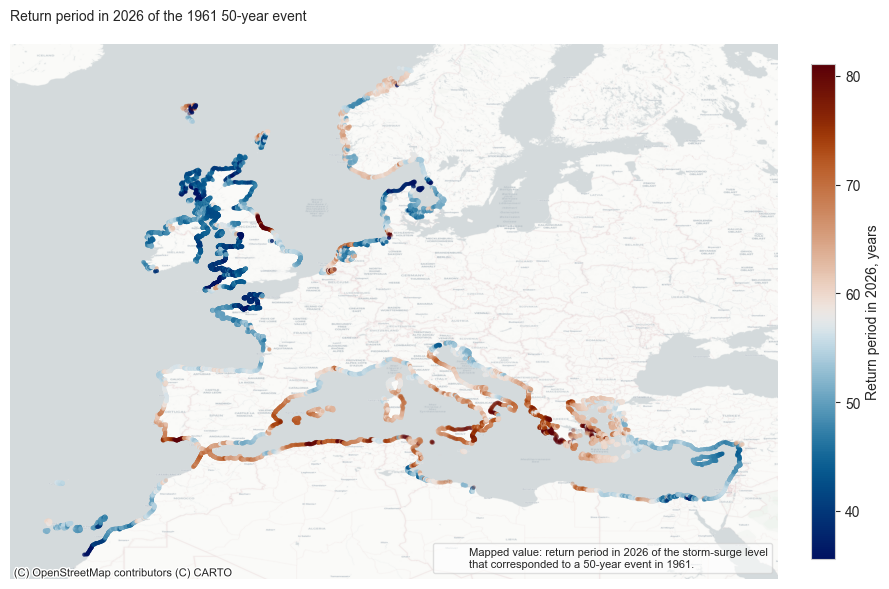

In [40]:
fig = plot_return_period_2026_static(
    df_rp2026,
    marker_size=8,
    mark_outlier=False,
    threshold_z_outlier=3,
    save_plot=True,
    save_path="../output/gev_analysis/2026-05-20/figures/ReturnPeriod_2026",
)